# AI1013: Programming for AI
## Assignment 5

### 1. Sampling via Inverse Transform Technique

Importing required libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

Setting the seed

In [3]:
np.random.seed(100)

Generating independent and identically distributed samples from uniform $(0,1)$

In [4]:
N=1000
array_samples_uniform = np.random.uniform(size=N)

Implementing the inverse CDF function $(F^{-1})$ for the given CDF $F$.

In [5]:
def inverse_cdf(y):
    #array where inverse will be stored
    x = np.zeros_like(y)
    indices1 = (y<0)

    indices2 = (y<1/3) & (y>=0)

    indices3 = (y<=2/3) & (y>=1/3)

    indices4 = (y<1) & (y> 2/3)
    
    indices5 = y>=1

    x[indices1] = 0
    x[indices2] = np.sqrt(3*y[indices2])
    x[indices3] = 2
    x[indices4] = 6*y[indices4] - 2
    x[indices5] = 4

    return x

Let's transform the uniform samples.

In [6]:
array_samples_custom = inverse_cdf(array_samples_uniform)

Let's now prepare the theoretical cdf for plotting.

In [7]:
#function to return cdf value for a particular x
def cdf(x):
    if x<0:
        return 0
    elif x<1:
        return x**2 /3
    elif x<2:
        return 1/3
    elif x<4:
        return (x+2)/6
    else:
        return 1

Applying the cdf to $x \in [-1,5]$

In [8]:
x_cdf = np.linspace(-1,5,N)
theoretical_cdf = np.zeros(N)
for i in range(N):
    theoretical_cdf[i] = cdf(x_cdf[i])

Now let's prepare the empirical cdf obtained by inverse transform technique for plotting

In [9]:
array_sorted_samples_custom = np.sort(array_samples_custom)
empirical_cdf = (np.arange(1,N+1, 1)) / N

Let's now plot them one by one, starting with the empirical CDF corresponding to `array_samples_custom`

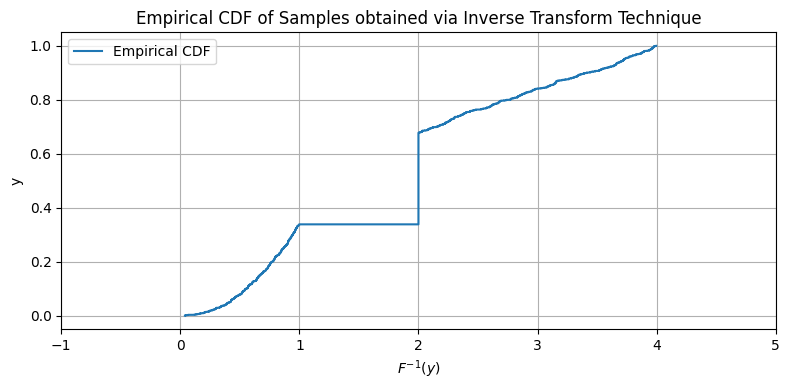

In [10]:
plt.figure(figsize=(8,4))
plt.step(array_sorted_samples_custom, empirical_cdf, label='Empirical CDF')
plt.xlabel(r'$F^{-1}(y)$')
plt.xlim((-1,5))
plt.ylabel('y')
plt.title('Empirical CDF of Samples obtained via Inverse Transform Technique')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Let's now plot the theoretical CDF, corresponding to `empirical_cdf`

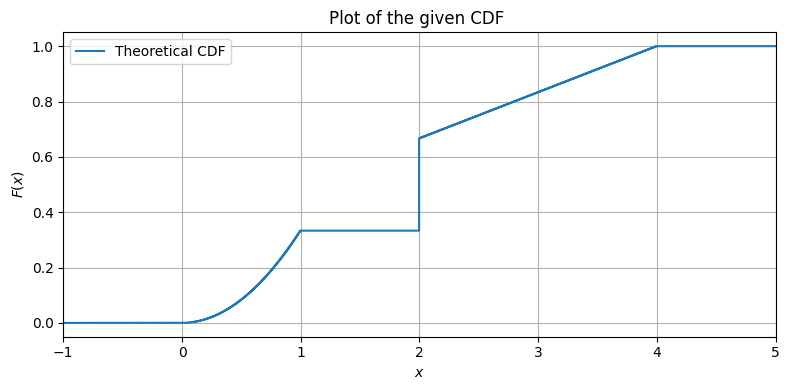

In [11]:
plt.figure(figsize=(8,4))
plt.step(x_cdf, theoretical_cdf, label='Theoretical CDF')
plt.xlabel(r'$x$')
plt.xlim((-1,5))
plt.ylabel(r'$F(x)$')
plt.title('Plot of the given CDF ')
plt.legend()    
plt.grid(True)
plt.tight_layout()
plt.show()

Both the empirical and theoretical CDF look similar, establishing the fact that the inverse transform technique accurately generates samples from any distribution, simply by choosing samples between 0 and 1 uniformly.

Let's now prepare to animate the plot.

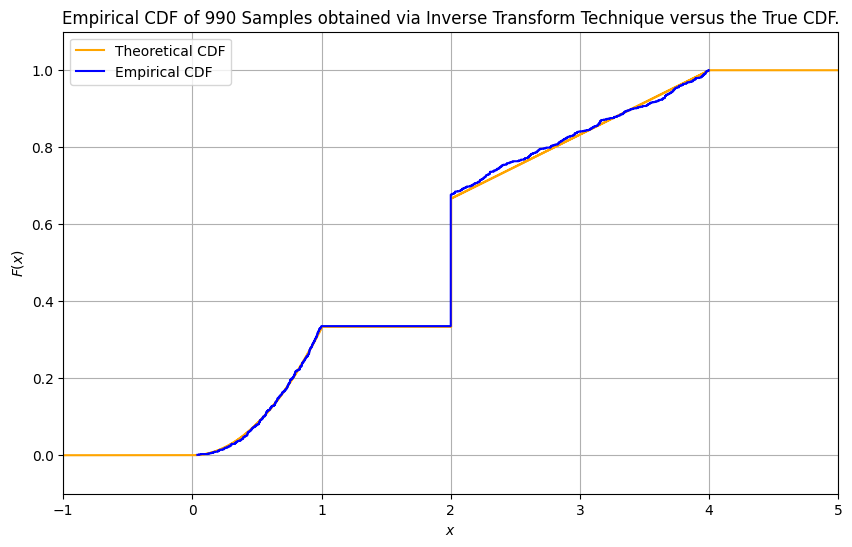

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

theoretical_plot = ax.step(x_cdf, theoretical_cdf, where='post', label="Theoretical CDF", color="orange")
empirical_line, = ax.step([], [], where='post', label="Empirical CDF", color="blue")

ax.set_xlim(-1, 5)
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$F(x)$')
ax.set_title('Empirical CDF of Samples obtained via Inverse Transform Technique versus the True CDF.')
ax.grid(True)
ax.legend()

n_values = []
n_values.extend(range(10, 100, 1))
n_values.extend(range(100, 500, 5))
n_values.extend(range(500, 1000, 10))

def init():
    empirical_line.set_data([], [])
    return empirical_line,

def update(frame):
    n =n_values[frame] if frame<len(n_values) else 1000

    samples = np.random.choice(array_sorted_samples_custom, n, replace=False)
    samples = np.sort(samples)
    empirical_cdf = (np.arange(1, n + 1)) / n

    empirical_line.set_data(samples, empirical_cdf)

    ax.set_title(f'Empirical CDF of {n} Samples obtained via Inverse Transform Technique versus the True CDF.')
    return empirical_line,

total_frames = len(n_values)
ani = FuncAnimation(fig, update, frames=total_frames, init_func=init, blit=True, interval=20)

#saving it
ani.save('./animation.mp4', fps=30)

#to display the animation in Jupyter Notebook, uncomment the following line

# from IPython.display import HTML
# HTML(ani.to_jshtml())


This animation shows us the convergence of the empirical CDF obtained by the **Inverse Transform Technique** to the True CDF. We observed that
1. For small values of N, the empirical CDF signifcantly deviates from the true CDF.
2. For medium valyes of N, the empirical CDF starts to be quite stable and also close to the true CDF.
3. For large values of N, the empirical CDF becomes almost the same as the true CDF.